In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [61]:
data = read_csv('Student_Performance.csv')

In [3]:
data

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [4]:
data.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [5]:
data["Extracurricular Activities"] = (data["Extracurricular Activities"] == "Yes").astype('int8')

array([[<Axes: title={'center': 'Hours Studied'}>,
        <Axes: title={'center': 'Previous Scores'}>],
       [<Axes: title={'center': 'Extracurricular Activities'}>,
        <Axes: title={'center': 'Sleep Hours'}>],
       [<Axes: title={'center': 'Sample Question Papers Practiced'}>,
        <Axes: title={'center': 'Performance Index'}>]], dtype=object)

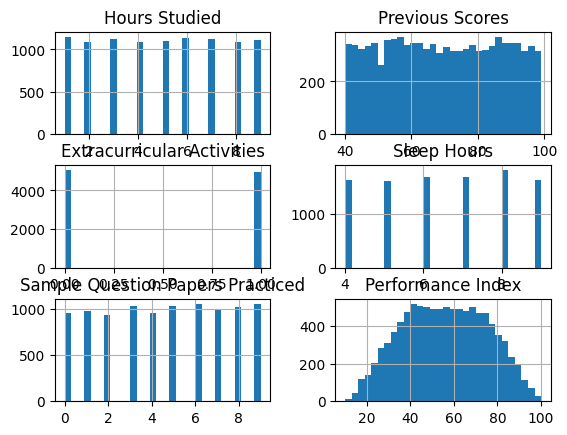

In [6]:
data.hist(bins=30)

In [7]:
pd.DataFrame(np.corrcoef(data, rowvar=False), columns=data.columns, index=data.columns)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.003873,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.008369,0.005944,0.007888,0.915189
Extracurricular Activities,0.003873,0.008369,1.000000,-0.023284,0.013103,0.024525
Sleep Hours,0.001245,0.005944,-0.023284,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.013103,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.024525,0.048106,0.043268,1.000000


In [8]:
y = data["Performance Index"].values
x = data.drop("Performance Index", axis=1)

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=37)

In [19]:
sc = MinMaxScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [20]:
model = LinearRegression()
model.fit(x_train_sc, y_train)
y_train_pred = model.predict(x_train_sc)
y_test_pred = model.predict(x_test_sc)
print(f'Train: {mean_absolute_error(y_train, y_train_pred)}, Test: {mean_absolute_error(y_test, y_test_pred)}')
print(model.coef_)

Train: 1.6133092304862735, Test: 1.634202951234822
[22.8623584  60.09296492  0.61614536  2.43326427  1.7372259 ]


In [31]:
model = LinearRegression()
model.fit(x_train, y_train)
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)
print(f'Train: {mean_absolute_error(y_train, y_train_pred)}, Test: {mean_absolute_error(y_test, y_test_pred)}')
print(model.coef_)

Train: 1.6133092304862733, Test: 1.6342029512348213
[2.8577948  1.01852483 0.61614536 0.48665285 0.1930251 ]


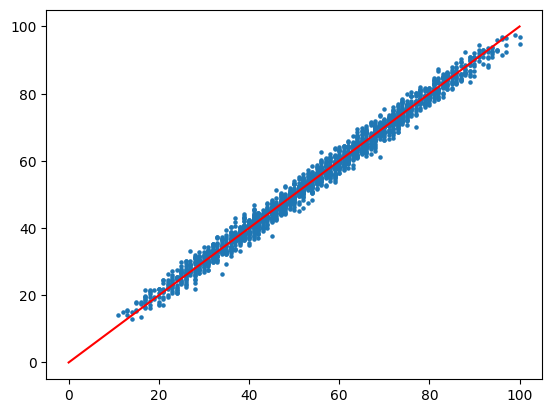

In [40]:
plt.scatter(y_test, y_test_pred, s=5)
plt.plot([0, 100], [0, 100], "r")

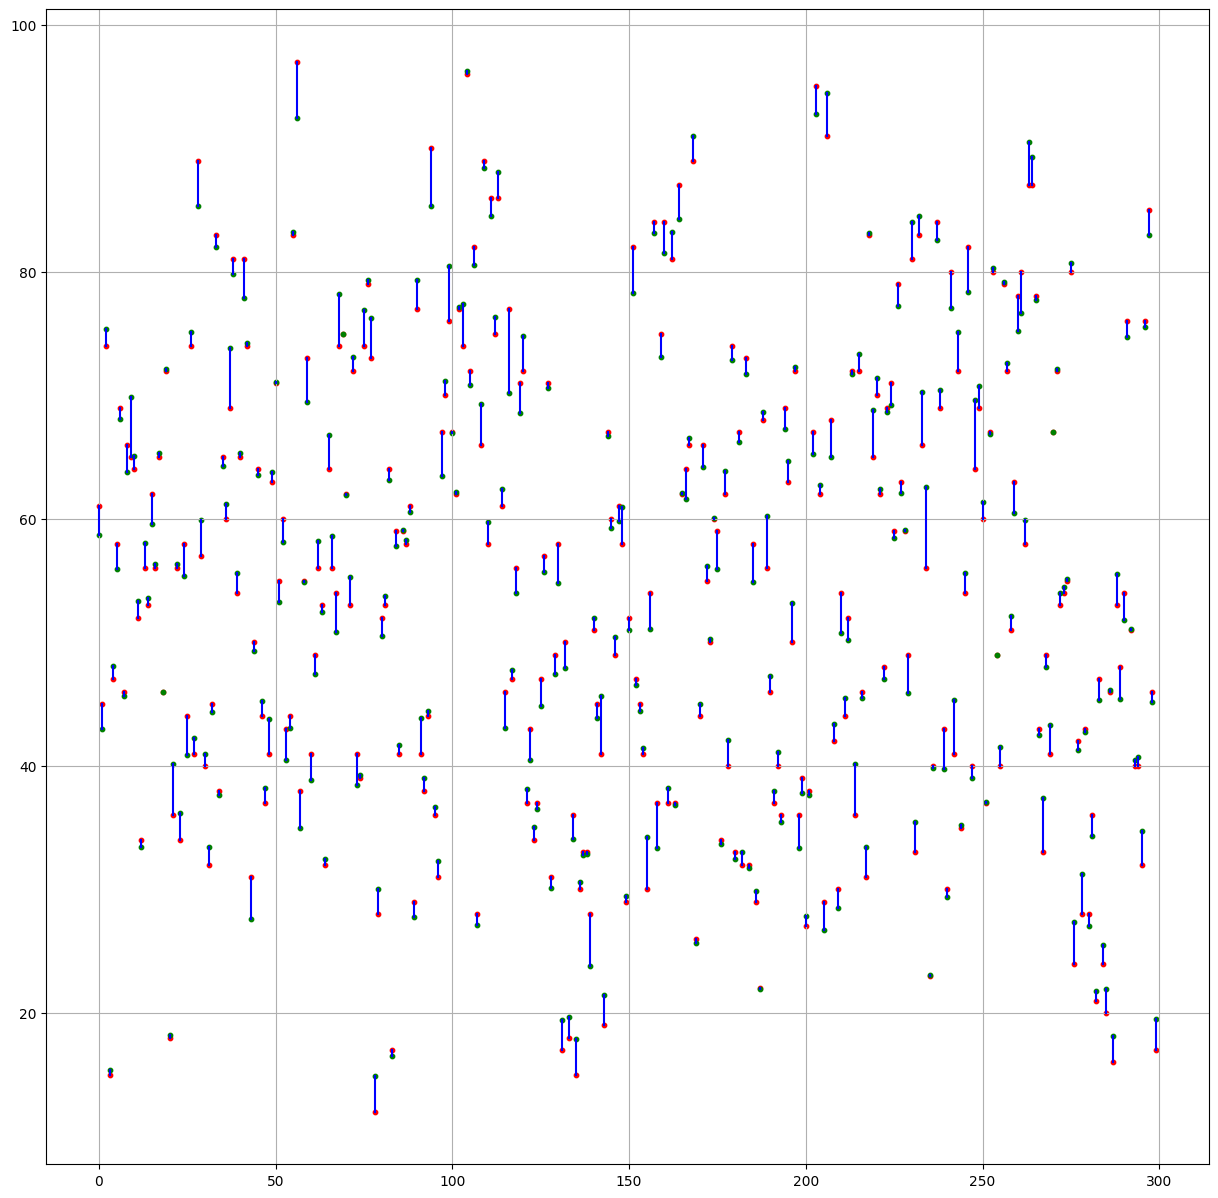

In [60]:
plt.figure(figsize=(15, 15))
plt.scatter(range(300), y_test[:300], s=10, c="r")
plt.scatter(range(300), y_test_pred[:300], s=10, c="g")

for i in range(300):
    plt.plot([i,i], [y_test[i], y_test_pred[i]], "b")
plt.grid()

In [16]:
x_train

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
1846,8,91,1,7,2
6463,2,63,0,8,9
7735,1,40,1,4,2
8493,2,78,0,9,1
171,4,90,0,7,9
...,...,...,...,...,...
4118,8,49,1,6,3
988,3,95,0,5,1
9036,9,63,1,8,7
4459,3,62,0,4,6


In [30]:
poly = PolynomialFeatures(degree = 2, include_bias=False)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)
print(x_train_poly.shape)
model = LinearRegression()
model.fit(x_train_poly, y_train)
y_train_pred = model.predict(x_train_poly)
y_test_pred = model.predict(x_test_poly)
print(f'Train: {mean_absolute_error(y_train, y_train_pred)}, Test: {mean_absolute_error(y_test, y_test_pred)}')

(8000, 20)
Train: 1.6115598172622718, Test: 1.6349609662909461
